In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# -----------------------------------------------
# Load CRIX and ETH log returns from one CSV file
# -----------------------------------------------

LOG_RETURNS_FILE = "../Data/crypto_and_crix_log_returns.csv"
SCATTER_COLUMNS = ["CRIX", "ETH"]

log_returns = pd.read_csv(
    LOG_RETURNS_FILE,
    index_col="Date",
    parse_dates=["Date"],
)

missing_columns = set(SCATTER_COLUMNS).difference(log_returns.columns)
if missing_columns:
    raise ValueError(f"Missing required return columns: {sorted(missing_columns)}")

crix_eth_log_returns = log_returns[SCATTER_COLUMNS].copy()
crix_eth_log_returns.index = pd.to_datetime(crix_eth_log_returns.index)


In [5]:
def animate_scatter_by_date(log_returns, points_per_frame=150, interval_ms=1000, save_path=None):
    """
    Animate CRIX vs ETH log returns growing point-by-point over time,
    colored by date, with a single updating date label (no ghosting).
    """
    plt.rcParams['font.family'] = 'serif'

    date_min = log_returns.index.min()
    date_max = log_returns.index.max()
    norm_vals = np.array((log_returns.index - date_min) / (date_max - date_min))
    total_points = len(log_returns)

    fig, ax = plt.subplots(figsize=(7, 7))

    sc = ax.scatter([], [], c=[], cmap='turbo', s=15, vmin=0, vmax=1)

    ax.axhline(0, color='grey', linewidth=1, zorder=0)
    ax.axvline(0, color='grey', linewidth=1, zorder=0)

    # Colorbar
    tick_dates = pd.date_range(date_min, date_max, periods=6)
    tick_positions = [(d - date_min) / (date_max - date_min) for d in tick_dates]
    cbar = fig.colorbar(sc, ax=ax, ticks=tick_positions)
    cbar.ax.set_yticklabels([d.strftime('%Y-%m-%d') for d in tick_dates])

    ax.set_xlabel('CRIX log return', fontsize=10)
    ax.set_ylabel('ETH log return', fontsize=10)
    ax.set_xlim(-0.48, 0.48)
    ax.set_ylim(-0.48, 0.48)
    ax.set_aspect('equal', adjustable='box')

    # Solid background to avoid GIF ghosting
    fig.patch.set_alpha(1.0)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1)

    # Use a proper title Text object
    title_obj = ax.set_title('', fontsize=10, pad=10)

    x_vals = log_returns["CRIX"].values
    y_vals = log_returns["ETH"].values
    frame_indices = list(range(points_per_frame, total_points + points_per_frame, points_per_frame))

    def init():
        sc.set_offsets(np.empty((0, 2)))
        sc.set_array(np.array([]))
        title_obj.set_text('')
        return sc, title_obj

    def update(frame_i):
        n = min(frame_i, total_points)
        sc.set_offsets(np.column_stack([x_vals[:n], y_vals[:n]]))
        sc.set_array(norm_vals[:n])
        current_date = log_returns.index[n - 1].strftime('%Y-%m-%d')
        title_obj.set_text(f'Date: {current_date}')
        return sc, title_obj

    ani = animation.FuncAnimation(
        fig, update, init_func=init,
        frames=frame_indices, interval=interval_ms, blit=True
    )

    if save_path is not None:
        if save_path.endswith('.gif'):
            ani.save(save_path, writer='pillow', fps=1000 / interval_ms)
        elif save_path.endswith('.mp4'):
            ani.save(save_path, writer='ffmpeg', fps=1000 / interval_ms)

    plt.show()
    return ani


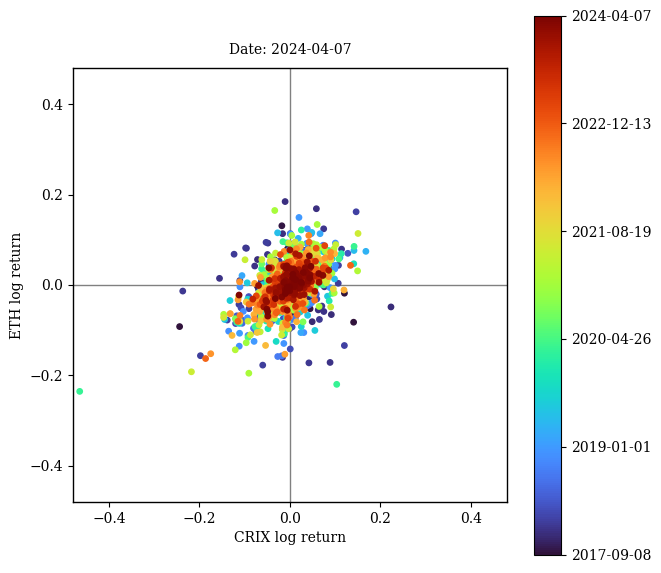

In [6]:
ani = animate_scatter_by_date(
    crix_eth_log_returns,
    points_per_frame=150,
    interval_ms=1000,
    save_path="crix_eth_anim.gif"
)